# MIOwAD - NN3

## Implementacja momentu i normalizacji gradientu

Zaimplementować dwa usprawnienia uczenia gradientowego sieci neuronowej:
- moment,
- normalizację gradientu RMSProp.

Porównać szybkość zbieżności procesu uczenia dla obu wariantów.

Przeprowadzić eksperymenty na zbiorach(w nawiasach wartość MSE, aby otrzymać 2 punkty):
- square-large (MSE: 1),
- steps-large (MSE: 6),
- multimodal-large (MSE: 9).

Literatura:
- Uczenie gradientowe z momentem: rozdział 3.2.2 Computational Intelligence, A. P. Engelbrecht
- Normalizacja gradientu: Wykład 6e: http://www.cs.toronto.edu/~tijmen/csc321/slides/lecture_slides_lec6.pdf

In [1]:
from utils import *

## 1. Sieci dla square-large

In [2]:
X_train, y_train, X_test, y_test = load_dataset(dataset_id=4)

print(X_train.shape, X_test.shape)

x_min, x_max = X_train.min(), X_train.max()
y_min, y_max = y_train.min(), y_train.max()

(1000, 1) (300, 1)


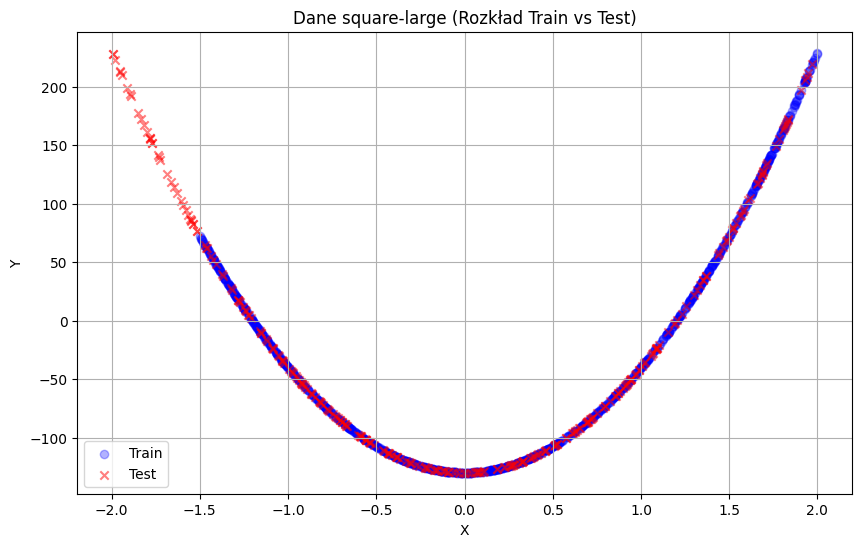

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.3, label='Train', marker='o')
plt.scatter(X_test, y_test, color='red', alpha=0.5, label='Test', marker='x')

plt.title('Dane square-large (Rozkład Train vs Test)')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.show()

In [3]:
square_1 = [
    {'name': 'SGD', 'batch_size': 32, 'epochs': 1000, 'lr': 0.01, 'optimizer': 'sgd'},
    {'name': 'Momentum', 'batch_size': 32, 'epochs': 1000, 'lr': 0.01, 'optimizer': 'momentum', 'momentum': 0.9},
    {'name': 'RMSProp', 'batch_size': 32, 'epochs': 1000, 'lr': 0.001, 'optimizer': 'rmsprop', 'beta': 0.9} 
]

results_square_1 = {}

--- TRENING: square-large ---
[*] TWORZĘ NOWY model 'SGD' i trenuję 1000 epok (lr=0.01)...
    -> Całkowity czas ukańczania:   4.07s | TEST MSE: 455.6275

[*] TWORZĘ NOWY model 'Momentum' i trenuję 1000 epok (lr=0.01)...
    -> Całkowity czas ukańczania:   4.46s | TEST MSE:  49.9018

[*] TWORZĘ NOWY model 'RMSProp' i trenuję 1000 epok (lr=0.001)...
    -> Całkowity czas ukańczania:   4.79s | TEST MSE:  56.1655



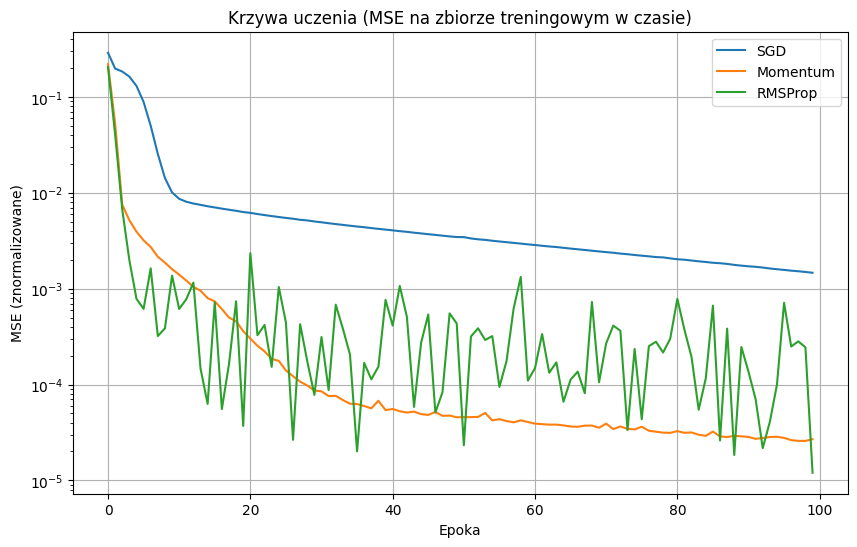

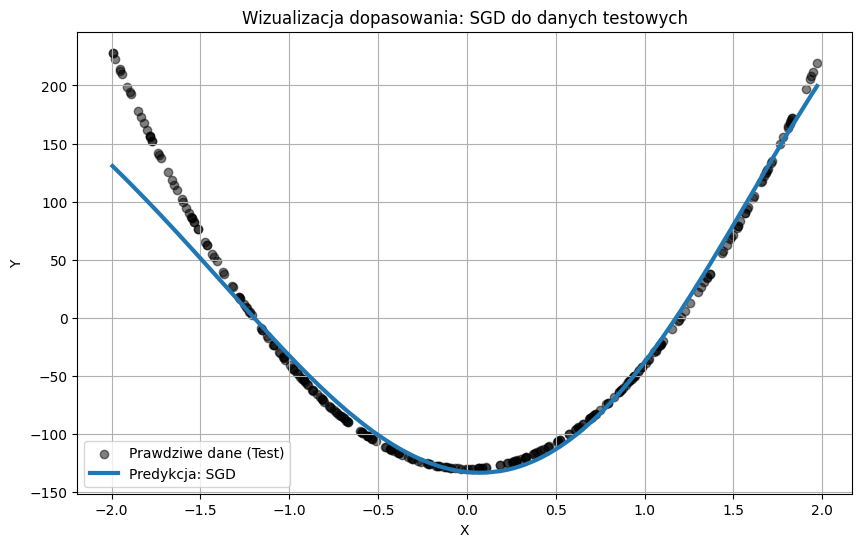

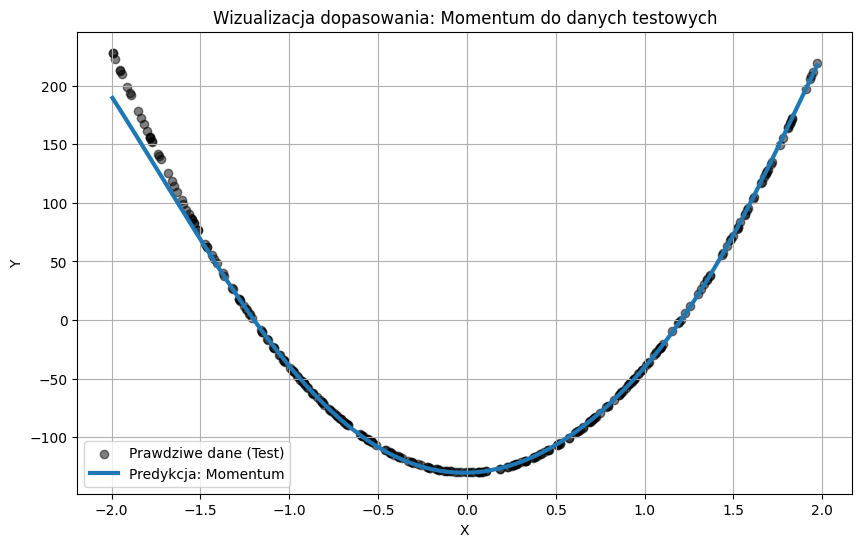

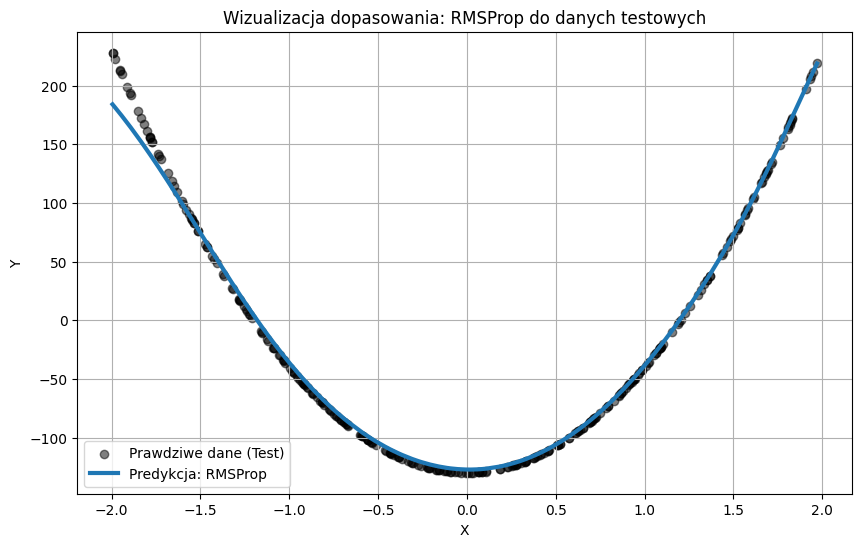

In [4]:
print("--- TRENING: square-large ---")
results_multi = train_and_evaluate(
    square_1, 
    results_square_1, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 20, 20, 1],  
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier',
    normalization_method='-1_1',
    loss_hist = 10
)

plot_loss_curves(results_square_1)

for opt_name in results_square_1.keys():
    plot_predictions(
        results_square_1, X_test, y_test, x_min, x_max, y_min, y_max, 
        name=opt_name,
        normalization_method='-1_1'
    )


--- TRENING: square-large ---
[*] TWORZĘ NOWY model 'Momentum' i trenuję 5000 epok (lr=0.01)...
    -> Całkowity czas ukańczania:  23.23s | TEST MSE:  19.9105

[*] TWORZĘ NOWY model 'RMSProp' i trenuję 5000 epok (lr=0.0005)...
    -> Całkowity czas ukańczania:  26.48s | TEST MSE:   8.3689



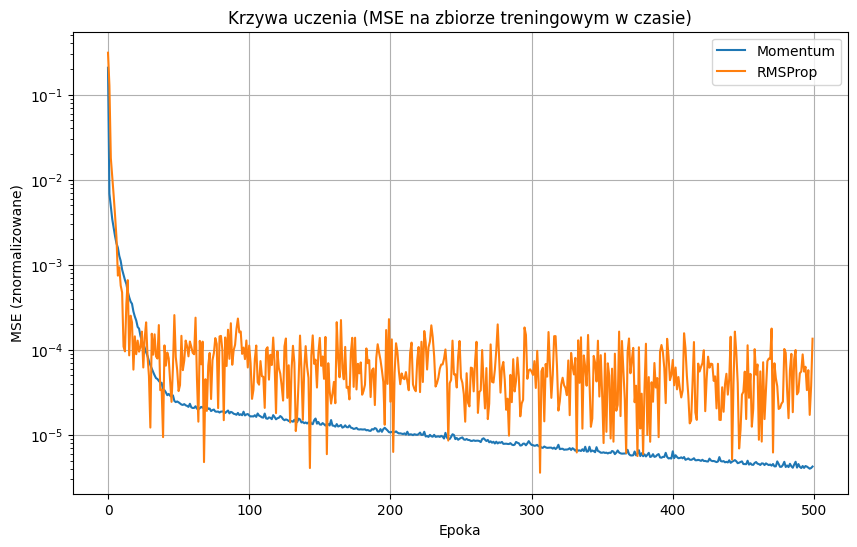

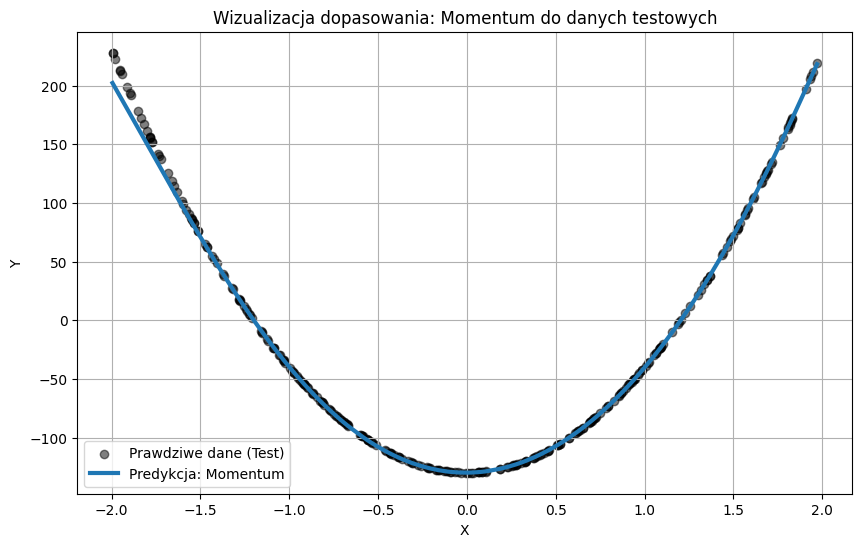

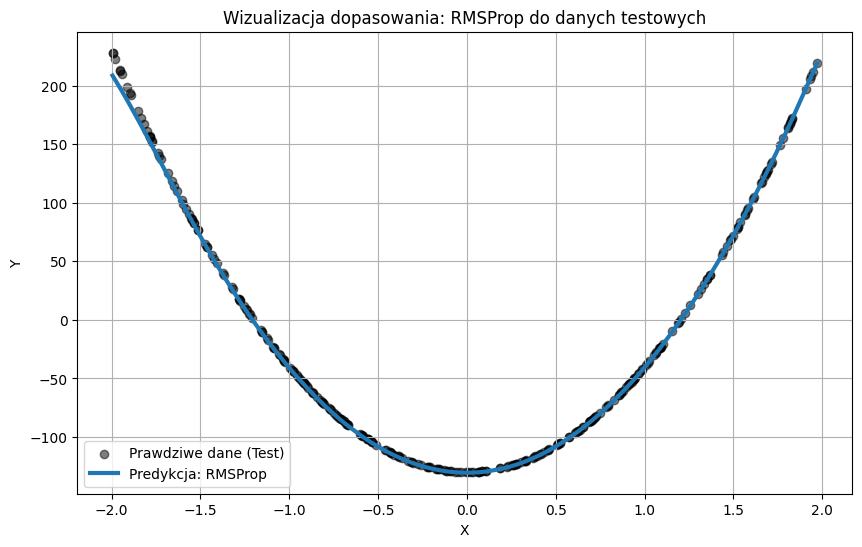

In [7]:
square_2 = [
    {'name': 'Momentum', 'batch_size': 32, 'epochs': 5000, 'lr': 0.01, 'optimizer': 'momentum', 'momentum': 0.9},
    {'name': 'RMSProp', 'batch_size': 32, 'epochs': 5000, 'lr': 0.0005, 'optimizer': 'rmsprop', 'beta': 0.9} 
]

results_square_2 = {}

print("--- TRENING: square-large ---")
results_multi = train_and_evaluate(
    square_2, 
    results_square_2, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 20, 20, 1],  
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier',
    normalization_method='-1_1',
    loss_hist = 10
)

plot_loss_curves(results_square_2)

for opt_name in results_square_2.keys():
    plot_predictions(
        results_square_2, X_test, y_test, x_min, x_max, y_min, y_max, 
        name=opt_name,
        normalization_method='-1_1'
    )


--- TRENING: square-large ---
[*] TWORZĘ NOWY model 'Momentum' i trenuję 20000 epok (lr=0.01)...
    -> Całkowity czas ukańczania: 215.79s | TEST MSE:  12.4504

[*] TWORZĘ NOWY model 'RMSProp' i trenuję 20000 epok (lr=0.001)...
    -> Całkowity czas ukańczania: 258.45s | TEST MSE: 452.5141



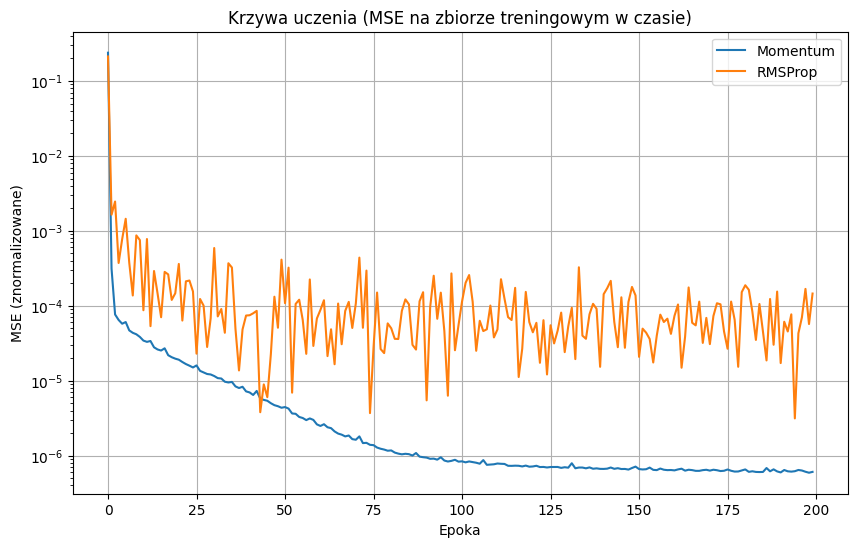

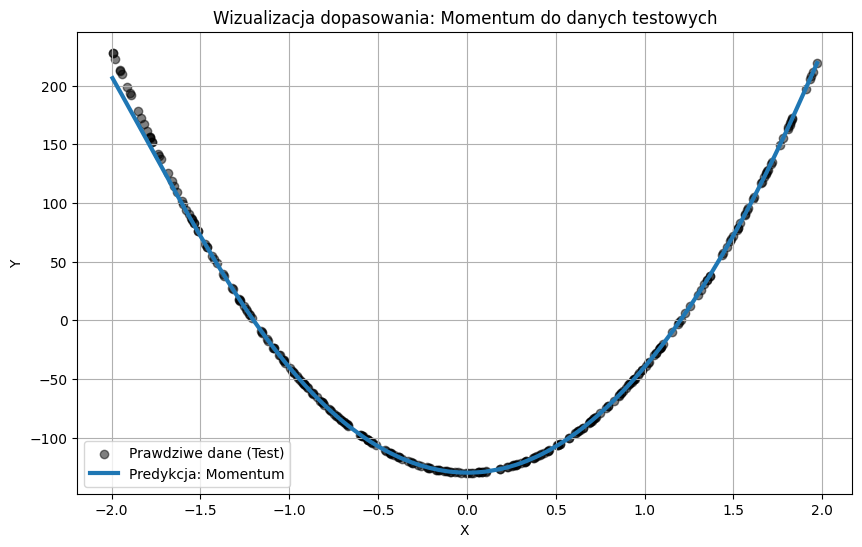

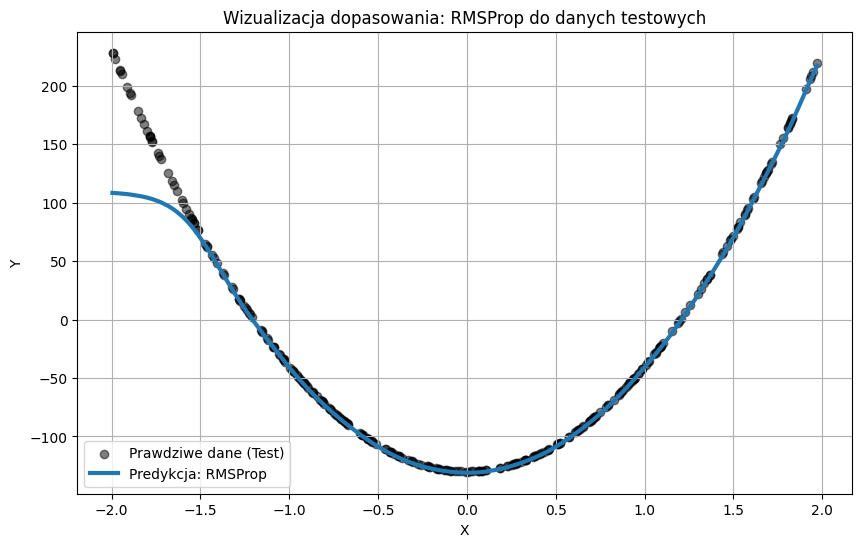

In [8]:
square_2 = [
    {'name': 'Momentum', 'batch_size': 32, 'epochs': 20000, 'lr': 0.01, 'optimizer': 'momentum', 'momentum': 0.9},
    {'name': 'RMSProp', 'batch_size': 32, 'epochs': 20000, 'lr': 0.001, 'optimizer': 'rmsprop', 'beta': 0.9} 
]

results_square_2 = {}

print("--- TRENING: square-large ---")
results_multi = train_and_evaluate(
    square_2, 
    results_square_2, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 40, 40, 1],  
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier',
    normalization_method='-1_1',
    loss_hist = 100
)

plot_loss_curves(results_square_2)

for opt_name in results_square_2.keys():
    plot_predictions(
        results_square_2, X_test, y_test, x_min, x_max, y_min, y_max, 
        name=opt_name,
        normalization_method='-1_1'
    )


--- TRENING: square-large ---
[*] TWORZĘ NOWY model 'Momentum' i trenuję 10000 epok (lr=0.005)...
    -> Całkowity czas ukańczania:  32.93s | TEST MSE:  40.2611

[*] TWORZĘ NOWY model 'RMSProp' i trenuję 10000 epok (lr=0.0002)...
    -> Całkowity czas ukańczania:  38.36s | TEST MSE:  36.9722



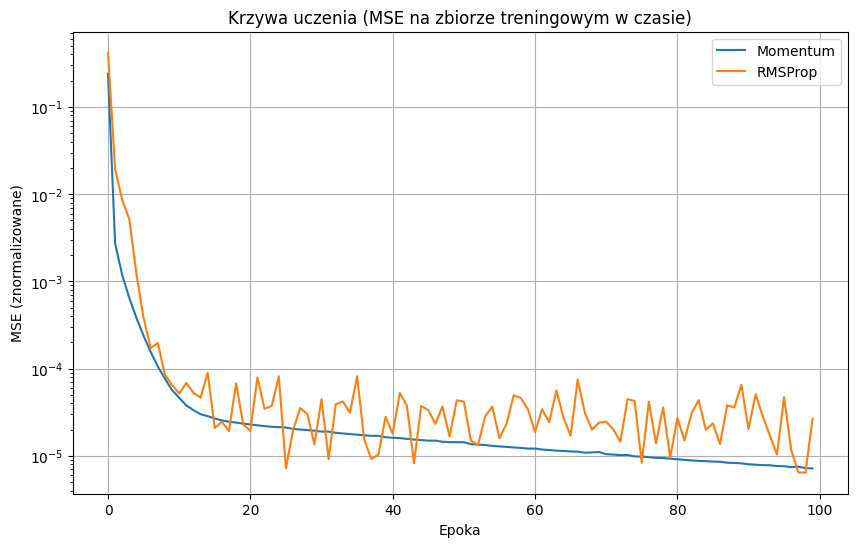

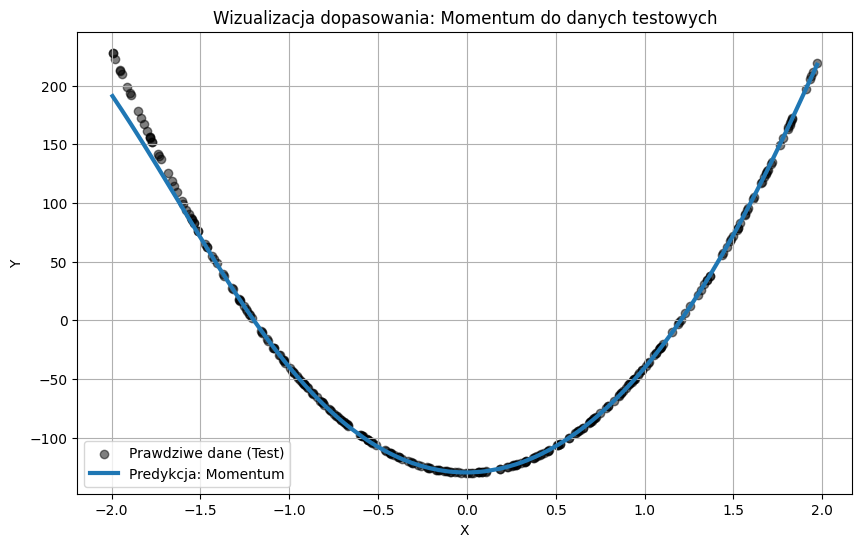

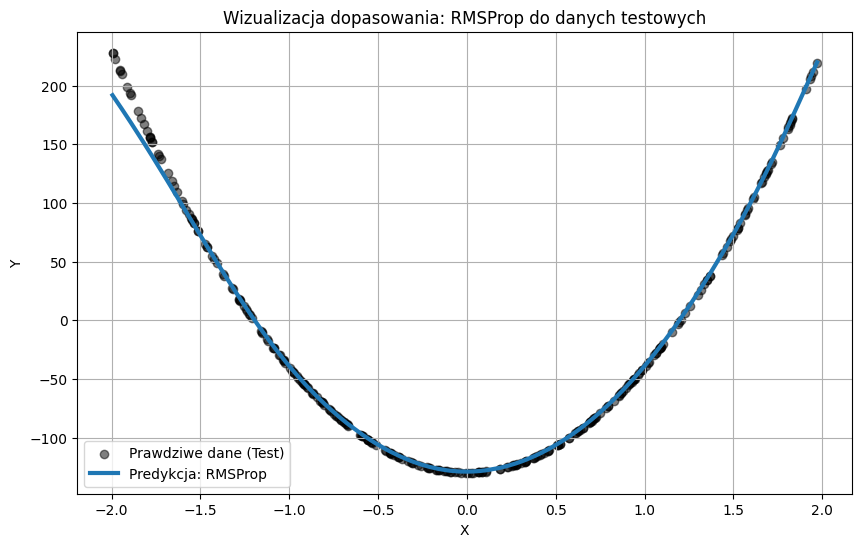

In [9]:
square_3 = [
    {'name': 'Momentum', 'batch_size': 64, 'epochs': 10000, 'lr': 0.005, 'optimizer': 'momentum', 'momentum': 0.9},
    {'name': 'RMSProp', 'batch_size': 64, 'epochs': 10000, 'lr': 0.0002, 'optimizer': 'rmsprop', 'beta': 0.9} 
]

results_square_3 = {}

print("--- TRENING: square-large ---")
results_multi = train_and_evaluate(
    square_3, 
    results_square_3, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 20, 20, 1],  
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier',
    normalization_method='-1_1',
    loss_hist = 100
)

plot_loss_curves(results_square_3)

for opt_name in results_square_3.keys():
    plot_predictions(
        results_square_3, X_test, y_test, x_min, x_max, y_min, y_max, 
        name=opt_name,
        normalization_method='-1_1'
    )


In [11]:
results_square_decay = {}
etapy = 5
epoki_na_etap = 4000

initial_lr_rms = 0.01
initial_lr_mom = 0.05

print("--- TRENING Z DECAY LR (square-large) ---")

for i in range(etapy):
    lr_rms = initial_lr_rms / (2**i)
    lr_mom = initial_lr_mom / (2**i)
    
    warianty_loop = [
        {'name': 'RMSProp', 'batch_size': 64, 'epochs': epoki_na_etap, 'lr': lr_rms, 'optimizer': 'rmsprop', 'beta': 0.9},
        {'name': 'Momentum', 'batch_size': 64, 'epochs': epoki_na_etap, 'lr': lr_mom, 'optimizer': 'momentum', 'momentum': 0.9}
    ]
    
    print(f"\n[!] ETAP {i+1}/{etapy} | LR RMSProp: {lr_rms:.6f} | LR Momentum: {lr_mom:.6f}")
    
    results_square_decay = train_and_evaluate(
        warianty_loop, 
        results_square_decay,
        X_train, y_train, X_test, y_test, 
        layer_sizes=[1, 30, 30, 1], 
        act_func=tanh, act_deriv=tanh_derivative, 
        init_method='xavier', 
        normalization_method='-1_1' 
    )


--- TRENING Z DECAY LR (square-large) ---

[!] ETAP 1/5 | LR RMSProp: 0.010000 | LR Momentum: 0.050000
[*] TWORZĘ NOWY model 'RMSProp' i trenuję 4000 epok (lr=0.01)...
    -> Całkowity czas ukańczania:  20.71s | TEST MSE: 728.7707

[*] TWORZĘ NOWY model 'Momentum' i trenuję 4000 epok (lr=0.05)...
    -> Całkowity czas ukańczania:  21.81s | TEST MSE:  18.9719


[!] ETAP 2/5 | LR RMSProp: 0.005000 | LR Momentum: 0.025000
[*] DOTRENOWUJĘ istniejący model 'RMSProp' o kolejne 4000 epok (lr=0.005)...
    -> Całkowity czas ukańczania:  47.24s | TEST MSE: 438.8137

[*] DOTRENOWUJĘ istniejący model 'Momentum' o kolejne 4000 epok (lr=0.025)...
    -> Całkowity czas ukańczania:  52.31s | TEST MSE:  17.0688


[!] ETAP 3/5 | LR RMSProp: 0.002500 | LR Momentum: 0.012500
[*] DOTRENOWUJĘ istniejący model 'RMSProp' o kolejne 4000 epok (lr=0.0025)...
    -> Całkowity czas ukańczania:  70.37s | TEST MSE: 315.7641

[*] DOTRENOWUJĘ istniejący model 'Momentum' o kolejne 4000 epok (lr=0.0125)...
    -> Całko

In [16]:
results_square_final = {}

square_final = [
    {'name': 'RMSProp', 'batch_size': 32, 'epochs': 20000, 'lr': 0.0001, 'optimizer': 'rmsprop', 'beta': 0.9},
    {'name': 'Momentum', 'batch_size': 32, 'epochs': 20000, 'lr': 0.02, 'optimizer': 'momentum', 'momentum': 0.9}
]

print("--- TRENING ---")
results_square_final = train_and_evaluate(
    square_final, 
    results_square_final, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 64, 64, 1], 
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier', 
    normalization_method='-1_1' 
)

--- TRENING ---
[*] TWORZĘ NOWY model 'RMSProp' i trenuję 20000 epok (lr=0.0001)...
    -> Całkowity czas ukańczania: 383.82s | TEST MSE:  43.4902

[*] TWORZĘ NOWY model 'Momentum' i trenuję 20000 epok (lr=0.02)...
    -> Całkowity czas ukańczania: 781.64s | TEST MSE:   9.2537



In [17]:
square_final2 = [
    {'name': 'RMSProp', 'batch_size': 32, 'epochs': 20000, 'lr': 0.00005, 'optimizer': 'rmsprop', 'beta': 0.9},
    {'name': 'Momentum', 'batch_size': 32, 'epochs': 20000, 'lr': 0.01, 'optimizer': 'momentum', 'momentum': 0.9}
]

print("--- TRENING ---")
results_square_final = train_and_evaluate(
    square_final2, 
    results_square_final, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 64, 64, 1], 
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier', 
    normalization_method='-1_1' 
)

--- TRENING ---
[*] DOTRENOWUJĘ istniejący model 'RMSProp' o kolejne 20000 epok (lr=5e-05)...
    -> Całkowity czas ukańczania: 945.52s | TEST MSE:  29.1810

[*] DOTRENOWUJĘ istniejący model 'Momentum' o kolejne 20000 epok (lr=0.01)...
    -> Całkowity czas ukańczania: 1076.57s | TEST MSE:   6.4477



In [18]:
square_final2 = [
    {'name': 'RMSProp', 'batch_size': 32, 'epochs': 20000, 'lr': 0.00005, 'optimizer': 'rmsprop', 'beta': 0.9},
    {'name': 'Momentum', 'batch_size': 32, 'epochs': 20000, 'lr': 0.005, 'optimizer': 'momentum', 'momentum': 0.9}
]

print("--- TRENING ---")
results_square_final = train_and_evaluate(
    square_final2, 
    results_square_final, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 64, 64, 1], 
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier', 
    normalization_method='-1_1' 
)

--- TRENING ---
[*] DOTRENOWUJĘ istniejący model 'RMSProp' o kolejne 20000 epok (lr=5e-05)...
    -> Całkowity czas ukańczania: 1555.25s | TEST MSE:  32.1995

[*] DOTRENOWUJĘ istniejący model 'Momentum' o kolejne 20000 epok (lr=0.005)...
    -> Całkowity czas ukańczania: 1616.06s | TEST MSE:   5.6195



In [19]:
square_final3 = [
    {'name': 'Momentum', 'batch_size': 32, 'epochs': 10000, 'lr': 0.001, 'optimizer': 'momentum', 'momentum': 0.9}
]

print("--- TRENING ---")
results_square_final = train_and_evaluate(
    square_final3, 
    results_square_final, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 64, 64, 1], 
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier', 
    normalization_method='-1_1' 
)

--- TRENING ---
[*] DOTRENOWUJĘ istniejący model 'Momentum' o kolejne 10000 epok (lr=0.001)...
    -> Całkowity czas ukańczania: 1890.29s | TEST MSE:   5.5856



## 2. Sieci dla steps-large

In [23]:
X_train, y_train, X_test, y_test = load_dataset(dataset_id=1)

print(X_train.shape, X_test.shape)

x_min, x_max = X_train.min(), X_train.max()
y_min, y_max = y_train.min(), y_train.max()

(10000, 1) (1000, 1)


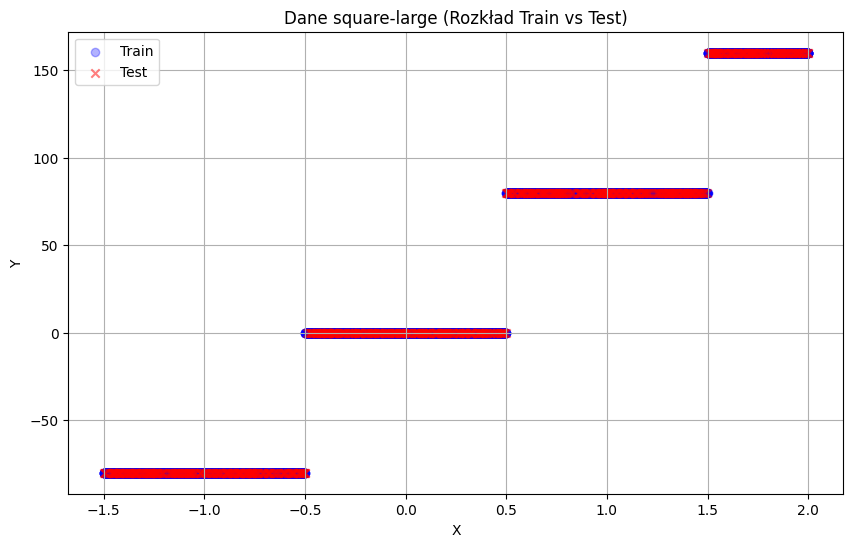

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.3, label='Train', marker='o')
plt.scatter(X_test, y_test, color='red', alpha=0.5, label='Test', marker='x')

plt.title('Dane square-large (Rozkład Train vs Test)')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
steps = [
    {'name': 'Momentum', 'batch_size': None, 'epochs': 10000, 'lr': 0.01, 'optimizer': 'momentum', 'momentum': 0.9},
    {'name': 'RMSProp', 'batch_size': None, 'epochs': 10000, 'lr': 0.001, 'optimizer': 'rmsprop', 'beta': 0.9} 
]

results_steps = {}

print("--- TRENING: steps-large ---")
results_steps = train_and_evaluate(
    steps, 
    results_steps, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 64, 64, 1],  
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier',
    normalization_method='-1_1',
    loss_hist = 1000
)

plot_loss_curves(results_steps)

for opt_name in results_steps.keys():
    plot_predictions(
        results_steps, X_test, y_test, x_min, x_max, y_min, y_max, 
        name=opt_name,
        normalization_method='-1_1'
    )


--- TRENING: steps-large ---
[*] TWORZĘ NOWY model 'Momentum' i trenuję 10000 epok (lr=0.01)...


## 3. Sieci dla multimodal-large

In [20]:
X_train, y_train, X_test, y_test = load_dataset(dataset_id=3)

print(X_train.shape, X_test.shape)

x_min, x_max = X_train.min(), X_train.max()
y_min, y_max = y_train.min(), y_train.max()

(10000, 1) (1000, 1)


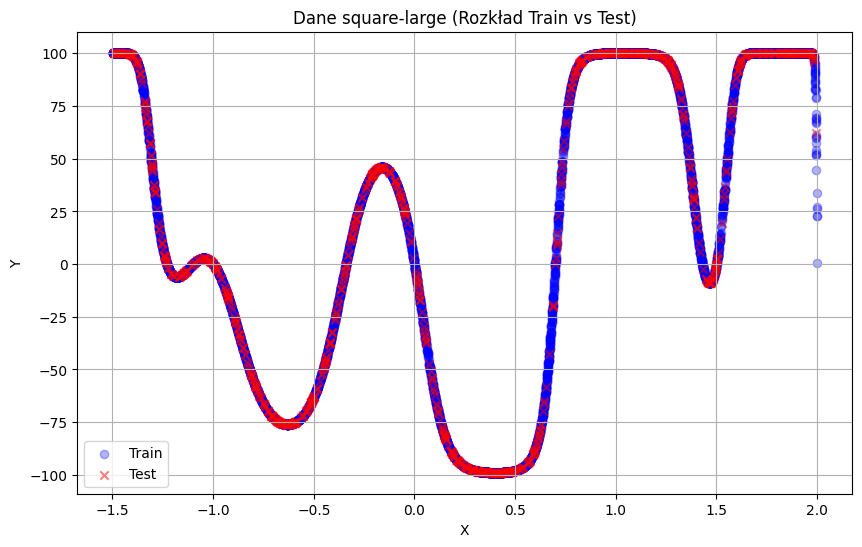

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.3, label='Train', marker='o')
plt.scatter(X_test, y_test, color='red', alpha=0.5, label='Test', marker='x')

plt.title('Dane square-large (Rozkład Train vs Test)')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.show()

--- TRENING: multimodal-large ---
[*] TWORZĘ NOWY model 'Momentum' i trenuję 2000 epok (lr=0.05)...
    -> Całkowity czas ukańczania: 158.62s | TEST MSE:   2.2604

[*] TWORZĘ NOWY model 'RMSProp' i trenuję 2000 epok (lr=0.001)...
    -> Całkowity czas ukańczania: 180.61s | TEST MSE:   3.7441



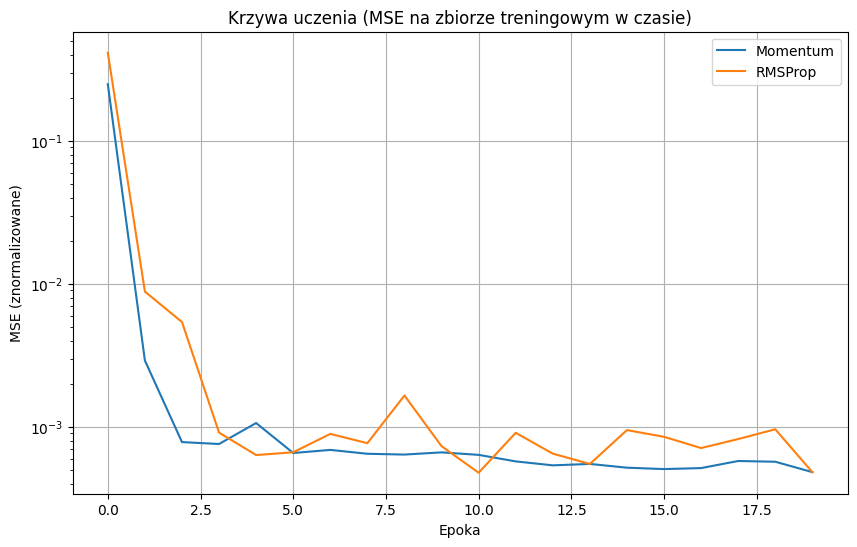

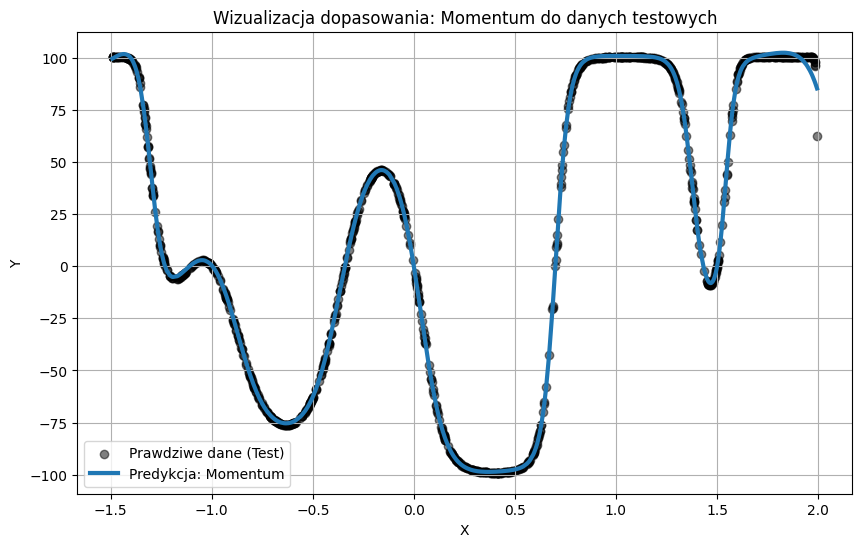

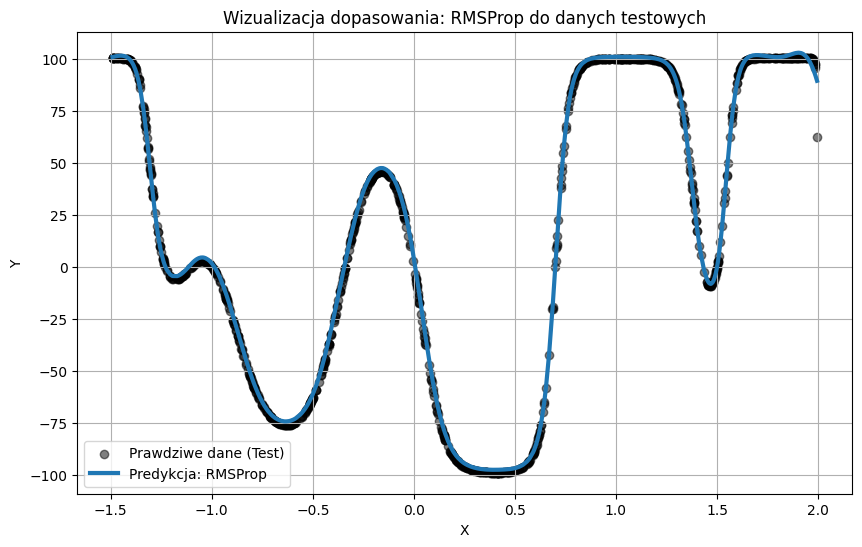

In [22]:
multi = [
    {'name': 'Momentum', 'batch_size': 64, 'epochs': 2000, 'lr': 0.05, 'optimizer': 'momentum', 'momentum': 0.9},
    {'name': 'RMSProp', 'batch_size': 64, 'epochs': 2000, 'lr': 0.001, 'optimizer': 'rmsprop', 'beta': 0.9} 
]

results_multi = {}

print("--- TRENING: multimodal-large ---")
results_multi = train_and_evaluate(
    multi, 
    results_multi, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 40, 40, 1],  
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier',
    normalization_method='-1_1',
    loss_hist = 100
)

plot_loss_curves(results_multi)

for opt_name in results_multi.keys():
    plot_predictions(
        results_multi, X_test, y_test, x_min, x_max, y_min, y_max, 
        name=opt_name,
        normalization_method='-1_1'
    )
